<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/FrozenLake_policy_iteration_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Policy Iteration для FrozenLake-v1

**Курс:** Numerical Programming in Python  
**Тема 9:** Випадкові процеси та їх застосування в аналізі даних

У роботі реалізовано алгоритм **ітерації за політиками (Policy Iteration)** для середовища `FrozenLake-v1`.

Основні етапи:

1. створення середовища;
2. оцінювання поточної політики через `compute_value_function()`;
3. покращення політики;
4. повторення кроків до отримання стабільної оптимальної політики;
5. візуалізація та перевірка отриманого результату.


## 1. Встановлення та імпорт бібліотек

In [1]:
# У Google Colab за потреби виконайте:
# !pip install -q gymnasium[toy-text]

import numpy as np
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
    GYMNASIUM = True
except ImportError:
    import gym
    GYMNASIUM = False

np.set_printoptions(precision=4, suppress=True)


## 2. Створення середовища FrozenLake-v1

Використовуємо стандартну карту `4x4`.

Параметр `is_slippery=True` означає, що середовище є стохастичним: агент не завжди рухається точно в обраному напрямку.


In [2]:
env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Кількість станів:", n_states)
print("Кількість дій:", n_actions)
print("Дії: 0 = LEFT, 1 = DOWN, 2 = RIGHT, 3 = UP")


Кількість станів: 16
Кількість дій: 4
Дії: 0 = LEFT, 1 = DOWN, 2 = RIGHT, 3 = UP


## 3. Матриця переходів середовища

Для кожної пари `(state, action)` середовище зберігає можливі переходи у форматі:

```text
(probability, next_state, reward, done)
```

Оскільки `FrozenLake-v1` є стохастичним, одна дія може приводити до кількох можливих наступних станів.


In [3]:
transition_model = env.unwrapped.P

example_state = 0
example_action = 1

print(
    f"Можливі переходи зі стану {example_state} "
    f"для дії {example_action}:"
)
transition_model[example_state][example_action]


Можливі переходи зі стану 0 для дії 1:


[(0.33333333333333337, 0, 0, False),
 (0.3333333333333333, 4, 0, False),
 (0.33333333333333337, 1, 0, False)]

## 4. Функція оцінювання політики

Для заданої політики обчислюємо функцію цінності станів:

$$
V^\pi(s)=
\sum_{s',r}
P(s',r \mid s,\pi(s))
\left[r+\gamma V^\pi(s')\right].
$$

Обчислення повторюється, доки максимальна зміна значень не стане меншою за `theta`.


In [4]:
def compute_value_function(
    env,
    policy,
    gamma=0.99,
    theta=1e-10,
    max_iterations=100_000
):
    """Обчислює функцію цінності для заданої детермінованої політики."""
    n_states = env.observation_space.n
    values = np.zeros(n_states)

    for iteration in range(max_iterations):
        delta = 0.0
        new_values = np.zeros(n_states)

        for state in range(n_states):
            action = int(policy[state])
            state_value = 0.0

            for probability, next_state, reward, done in env.unwrapped.P[state][action]:
                future_value = 0.0 if done else values[next_state]
                state_value += probability * (
                    reward + gamma * future_value
                )

            new_values[state] = state_value
            delta = max(delta, abs(new_values[state] - values[state]))

        values = new_values

        if delta < theta:
            return values, iteration + 1

    raise RuntimeError(
        "Policy evaluation did not converge within max_iterations."
    )


## 5. Обчислення цінності всіх можливих дій

In [5]:
def action_values(env, state, values, gamma=0.99):
    """Обчислює очікувану цінність кожної дії у заданому стані."""
    n_actions = env.action_space.n
    q_values = np.zeros(n_actions)

    for action in range(n_actions):
        for probability, next_state, reward, done in env.unwrapped.P[state][action]:
            future_value = 0.0 if done else values[next_state]
            q_values[action] += probability * (
                reward + gamma * future_value
            )

    return q_values


## 6. Реалізація Policy Iteration

Алгоритм складається з двох кроків:

1. **Policy evaluation** — оцінювання поточної політики.
2. **Policy improvement** — вибір найкращої дії в кожному стані.

Алгоритм завершується, коли після покращення політика більше не змінюється.


In [6]:
def policy_iteration(
    env,
    gamma=0.99,
    theta=1e-10,
    max_policy_iterations=1_000
):
    """Знаходить оптимальну детерміновану політику методом Policy Iteration."""
    n_states = env.observation_space.n

    # Початкова політика: для всіх станів обираємо дію LEFT.
    policy = np.zeros(n_states, dtype=int)
    evaluation_iterations = []

    for policy_iteration_number in range(max_policy_iterations):
        values, n_eval_iterations = compute_value_function(
            env=env,
            policy=policy,
            gamma=gamma,
            theta=theta
        )
        evaluation_iterations.append(n_eval_iterations)

        policy_stable = True
        improved_policy = policy.copy()

        for state in range(n_states):
            old_action = int(policy[state])
            q_values = action_values(env, state, values, gamma)
            best_action = int(np.argmax(q_values))

            improved_policy[state] = best_action

            if best_action != old_action:
                policy_stable = False

        policy = improved_policy

        if policy_stable:
            return {
                "policy": policy,
                "values": values,
                "policy_iterations": policy_iteration_number + 1,
                "evaluation_iterations": evaluation_iterations,
            }

    raise RuntimeError(
        "Policy iteration did not converge within max_policy_iterations."
    )


## 7. Отримання оптимальної політики

In [7]:
result = policy_iteration(
    env,
    gamma=0.99,
    theta=1e-10
)

optimal_policy = result["policy"]
optimal_values = result["values"]

print("Оптимальна політика:")
print(optimal_policy.reshape(4, 4))

print("\nФункція цінності:")
print(optimal_values.reshape(4, 4))

print("\nКількість ітерацій покращення політики:",
      result["policy_iterations"])
print("Кількість ітерацій оцінювання на кожному кроці:",
      result["evaluation_iterations"])


Оптимальна політика:
[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

Функція цінності:
[[0.542  0.4988 0.4707 0.4569]
 [0.5585 0.     0.3583 0.    ]
 [0.5918 0.6431 0.6152 0.    ]
 [0.     0.7417 0.8628 0.    ]]

Кількість ітерацій покращення політики: 7
Кількість ітерацій оцінювання на кожному кроці: [1, 42, 213, 225, 454, 483, 574]


## 8. Візуалізація оптимальної політики

Позначення:

- `←` — рух ліворуч;
- `↓` — рух униз;
- `→` — рух праворуч;
- `↑` — рух угору;
- `S` — старт;
- `F` — безпечна клітинка;
- `H` — ополонка;
- `G` — ціль.


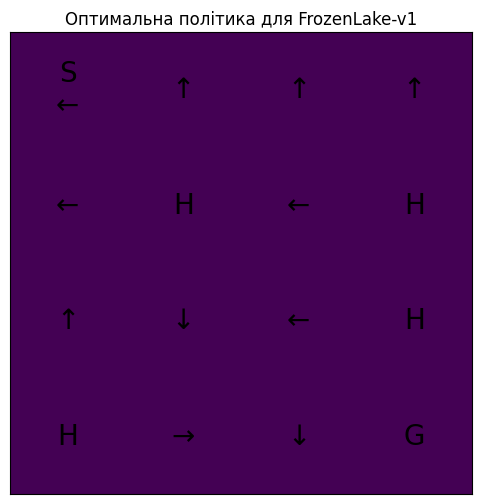

In [8]:
ACTION_SYMBOLS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑",
}


def show_policy(policy, env):
    """Візуалізує оптимальну політику для карти FrozenLake."""
    desc = env.unwrapped.desc.astype(str)
    rows, cols = desc.shape
    policy_grid = policy.reshape(rows, cols)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.zeros((rows, cols)))

    for row in range(rows):
        for col in range(cols):
            tile = desc[row, col]
            state = row * cols + col

            if tile in {"H", "G"}:
                text = tile
            elif tile == "S":
                text = f"S\n{ACTION_SYMBOLS[policy_grid[row, col]]}"
            else:
                text = ACTION_SYMBOLS[policy_grid[row, col]]

            ax.text(
                col,
                row,
                text,
                ha="center",
                va="center",
                fontsize=20
            )

    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which="minor", linewidth=2)
    ax.tick_params(
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False
    )
    ax.set_title("Оптимальна політика для FrozenLake-v1")
    plt.show()


show_policy(optimal_policy, env)


## 9. Функція `show_render()`

Функція нижче запускає один епізод відповідно до отриманої політики та виводить послідовність станів.

У Colab графічне вікно Gym може не відкриватися, тому використовується текстовий режим `ansi`.


In [9]:
def show_render(policy, max_steps=100, seed=42):
    """Запускає один епізод і показує проходження середовища."""
    render_env = gym.make(
        "FrozenLake-v1",
        is_slippery=True,
        render_mode="ansi"
    )

    reset_result = render_env.reset(seed=seed)
    state = reset_result[0] if isinstance(reset_result, tuple) else reset_result

    total_reward = 0.0

    print(render_env.render())

    for step in range(max_steps):
        action = int(policy[state])
        step_result = render_env.step(action)

        if len(step_result) == 5:
            next_state, reward, terminated, truncated, info = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, info = step_result

        total_reward += reward
        state = next_state

        print(f"Крок {step + 1}, дія: {ACTION_SYMBOLS[action]}")
        print(render_env.render())

        if done:
            break

    render_env.close()

    print("Кількість кроків:", step + 1)
    print("Сумарна винагорода:", total_reward)

    return total_reward


show_render(optimal_policy)



SFFF
FHFH
FFFH
HFFG

Крок 1, дія: ←
  (Left)
SFFF
FHFH
FFFH
HFFG

Крок 2, дія: ←
  (Left)
SFFF
FHFH
FFFH
HFFG

Крок 3, дія: ←
  (Left)
SFFF
FHFH
FFFH
HFFG

Крок 4, дія: ↑
  (Up)
SFFF
FHFH
FFFH
HFFG

Крок 5, дія: ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Крок 6, дія: ←
  (Left)
SFFF
FHFH
FFFH
HFFG

Крок 7, дія: ↓
  (Down)
SFFF
FHFH
FFFH
HFFG

Кількість кроків: 7
Сумарна винагорода: 1.0


1.0

## 10. Обчислювальний експеримент

Оскільки середовище стохастичне, один запуск не дає достатньої інформації. Проведемо багато епізодів та оцінимо частку успішних проходжень.


In [10]:
def evaluate_policy(env_name, policy, episodes=1_000, seed=123):
    """Оцінює політику за часткою успішних епізодів."""
    eval_env = gym.make(env_name, is_slippery=True)
    rewards = []
    episode_lengths = []

    for episode in range(episodes):
        reset_result = eval_env.reset(seed=seed + episode)
        state = reset_result[0] if isinstance(reset_result, tuple) else reset_result

        total_reward = 0.0

        for step in range(100):
            action = int(policy[state])
            step_result = eval_env.step(action)

            if len(step_result) == 5:
                next_state, reward, terminated, truncated, info = step_result
                done = terminated or truncated
            else:
                next_state, reward, done, info = step_result

            total_reward += reward
            state = next_state

            if done:
                episode_lengths.append(step + 1)
                break

        rewards.append(total_reward)

    eval_env.close()

    return {
        "success_rate": float(np.mean(rewards)),
        "average_reward": float(np.mean(rewards)),
        "average_episode_length": float(np.mean(episode_lengths)),
    }


evaluation = evaluate_policy(
    "FrozenLake-v1",
    optimal_policy,
    episodes=1_000
)

evaluation


{'success_rate': 0.746,
 'average_reward': 0.746,
 'average_episode_length': 44.722}

## 11. Експеримент із різними значеннями коефіцієнта дисконтування

Перевіримо, як значення `gamma` впливає на отриману політику, кількість ітерацій та успішність.


In [11]:
gammas = [0.80, 0.90, 0.95, 0.99]
experiment_results = []

for gamma in gammas:
    current_result = policy_iteration(
        env,
        gamma=gamma,
        theta=1e-10
    )

    current_evaluation = evaluate_policy(
        "FrozenLake-v1",
        current_result["policy"],
        episodes=1_000,
        seed=500
    )

    experiment_results.append({
        "gamma": gamma,
        "policy_iterations": current_result["policy_iterations"],
        "success_rate": current_evaluation["success_rate"],
        "average_episode_length":
            current_evaluation["average_episode_length"],
        "policy": current_result["policy"].reshape(4, 4),
    })

for item in experiment_results:
    print(f"\ngamma = {item['gamma']}")
    print("Policy iterations:", item["policy_iterations"])
    print("Success rate:", round(item["success_rate"], 4))
    print(
        "Average episode length:",
        round(item["average_episode_length"], 2)
    )
    print(item["policy"])



gamma = 0.8
Policy iterations: 5
Success rate: 0.467
Average episode length: 27.16
[[1 3 2 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

gamma = 0.9
Policy iterations: 6
Success rate: 0.732
Average episode length: 40.67
[[0 3 0 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

gamma = 0.95
Policy iterations: 6
Success rate: 0.732
Average episode length: 40.67
[[0 3 0 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

gamma = 0.99
Policy iterations: 7
Success rate: 0.736
Average episode length: 44.3
[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]


## Висновки

У роботі було реалізовано алгоритм ітерації за політиками для середовища `FrozenLake-v1`.

Функція `compute_value_function()` ітеративно оцінює функцію цінності для заданої політики. Функція `policy_iteration()` по черзі виконує оцінювання та покращення політики, доки вона не стане стабільною.

Отримана оптимальна політика враховує стохастичність середовища. Через параметр `is_slippery=True` навіть оптимальна дія не гарантує успішного переходу, тому частка успішних епізодів є меншою за 100%.

Додатковий експеримент із різними значеннями `gamma` показує, що коефіцієнт дисконтування може впливати на оцінки станів, кількість ітерацій та вибір оптимальних дій. Для цієї задачі велике значення `gamma`, наприклад `0.99`, є доцільним, оскільки винагорода надходить лише після досягнення цільової клітинки.
